## **Importation et chargement des données**

In [1]:
# Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv("Loan_Data.csv")

# Afficher les premières lignes
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


## **Découvertes des données et feature engineering**

In [2]:
# Informations générales sur le dataset
print("Nombre de clients :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])
print()
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print()
print("Statistiques générales :")
df.describe()

Nombre de clients : 10000
Nombre de colonnes : 8

Valeurs manquantes par colonne :
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Statistiques générales :


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [12]:
# Détection d'anomalies avec l'écart interquartile (IQR)
print("=== Détection d'anomalies ===\n")

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    anomalies = X[(X[col] < Q1 - 1.5 * IQR) | (X[col] > Q3 + 1.5 * IQR)]
    print(f"{col} : {len(anomalies)} anomalies détectées")

=== Détection d'anomalies ===

credit_lines_outstanding : 0 anomalies détectées
loan_amt_outstanding : 115 anomalies détectées
total_debt_outstanding : 602 anomalies détectées
income : 86 anomalies détectées
years_employed : 0 anomalies détectées
fico_score : 72 anomalies détectées


/tmp/ipykernel_12002/28242725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clean['default'], y=df_clean[col], palette=['steelblue', 'tomato'])
/tmp/ipykernel_12002/28242725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clean['default'], y=df_clean[col], palette=['steelblue', 'tomato'])
/tmp/ipykernel_12002/28242725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clean['default'], y=df_clean[col], palette=['steelblue', 'tomato'])
/tmp/ipykernel_12002/28242725.py:5: FutureWarning: 

Passing `palette` without ass

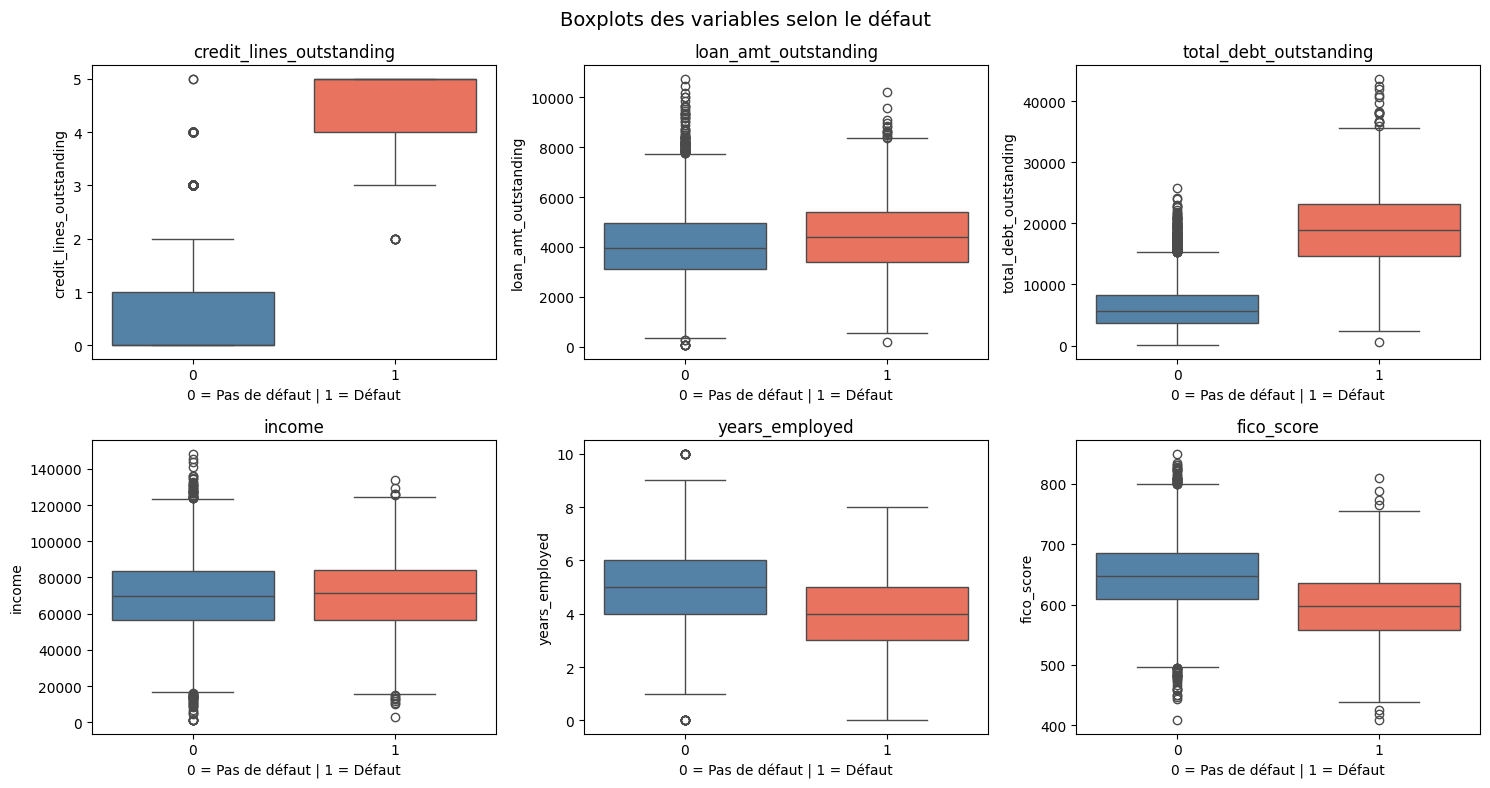

In [15]:
# Détection d'anomalies par Boxplot
plt.figure(figsize=(15, 8))
for i, col in enumerate(X.columns):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df_clean['default'], y=df_clean[col], palette=['steelblue', 'tomato'])
    plt.title(f"{col}")
    plt.xlabel("0 = Pas de défaut | 1 = Défaut")
plt.suptitle("Boxplots des variables selon le défaut", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
from scipy import stats
import numpy as np

print("=== Détection d'anomalies par Z-Score ===\n")

for col in X.columns:
    z_scores = np.abs(stats.zscore(X[col]))
    anomalies = (z_scores > 3).sum()
    print(f"{col} : {anomalies} anomalies détectées (Z-Score > 3)")

=== Détection d'anomalies par Z-Score ===

credit_lines_outstanding : 0 anomalies détectées (Z-Score > 3)
loan_amt_outstanding : 41 anomalies détectées (Z-Score > 3)
total_debt_outstanding : 143 anomalies détectées (Z-Score > 3)
income : 30 anomalies détectées (Z-Score > 3)
years_employed : 11 anomalies détectées (Z-Score > 3)
fico_score : 26 anomalies détectées (Z-Score > 3)


In [14]:
print("-- Décision sur les anomalies --\n")
print("Les anomalies détectées représentent moins de 6% des données.")
print("Dans le domaine bancaire, ces valeurs extrêmes peuvent être réelles.")
print("Décision : on conserve ces valeurs dans le dataset.")

-- Décision sur les anomalies --

Les anomalies détectées représentent moins de 6% des données.
Dans le domaine bancaire, ces valeurs extrêmes peuvent être réelles.
Décision : on conserve ces valeurs dans le dataset.


In [26]:
# Feature Engineering (création de nouvelles variables)
print("=== Feature Engineering ===\n")

# Ratio dette/revenu
df_clean['debt_to_income'] = df_clean['total_debt_outstanding'] / df_clean['income']

# Ratio prêt/revenu
df_clean['loan_to_income'] = df_clean['loan_amt_outstanding'] / df_clean['income']

# Charge financière totale
df_clean['financial_burden'] = df_clean['credit_lines_outstanding'] * df_clean['loan_amt_outstanding']

# Dette par crédit
df_clean['debt_per_credit_line'] = df_clean['total_debt_outstanding'] / (df_clean['credit_lines_outstanding'] + 1)

# Revenu par année d'expérience
df_clean['income_per_year_employed'] = df_clean['income'] / (df_clean['years_employed'] + 1)

print("Nouvelles variables créées :")
print("- debt_to_income : ratio dette/revenu")
print("- loan_to_income : ratio prêt/revenu")
print("- financial_burden : charge financière totale")
print("- debt_per_credit_line : dette par crédit")
print("- income_per_year_employed : revenu par année d'expérience")
print()
df_clean[['debt_to_income', 'loan_to_income', 'financial_burden',
          'debt_per_credit_line', 'income_per_year_employed']].describe()

=== Feature Engineering ===

Nouvelles variables créées :
- debt_to_income : ratio dette/revenu
- loan_to_income : ratio prêt/revenu
- financial_burden : charge financière totale
- debt_per_credit_line : dette par crédit
- income_per_year_employed : revenu par année d'expérience



,debt_to_income,loan_to_income,financial_burden,debt_per_credit_line,income_per_year_employed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.124018,0.059423,6277.013322,3726.979530,13964.772735
std,0.082802,0.010642,8398.151100,1702.797189,7165.828783
min,0.010000,0.012249,0.000000,31.652732,90.909091
25%,0.068533,0.052125,0.000000,2613.271640,9566.945817
50%,0.097434,0.059517,3362.588193,3554.117100,12666.806787
75%,0.163385,0.066717,9183.261400,4616.048172,16621.387715
max,0.404561,0.102103,51053.733450,13531.594250,121346.051400


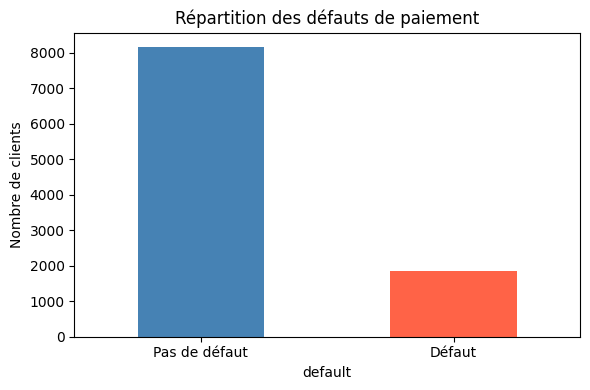

In [18]:
# Répartition des défauts
plt.figure(figsize=(6,4))
df['default'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Répartition des défauts de paiement")
plt.xticks([0, 1], ['Pas de défaut', 'Défaut'], rotation=0)
plt.ylabel("Nombre de clients")
plt.tight_layout()
plt.show()


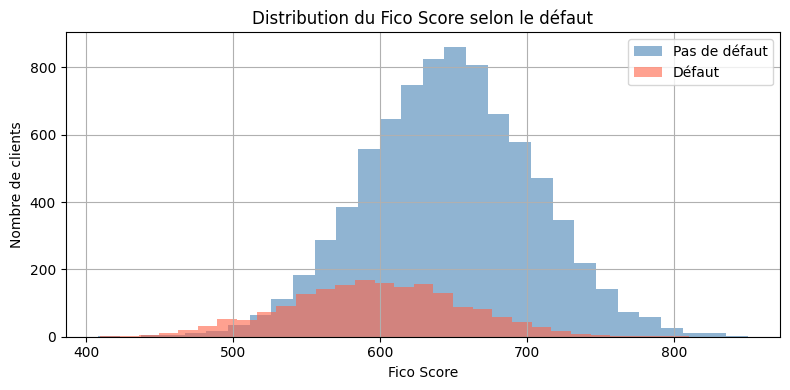

In [19]:
# Distribution du fico_score selon le défaut
plt.figure(figsize=(8,4))
df[df['default']==0]['fico_score'].hist(alpha=0.6, label='Pas de défaut', color='steelblue', bins=30)
df[df['default']==1]['fico_score'].hist(alpha=0.6, label='Défaut', color='tomato', bins=30)
plt.title("Distribution du Fico Score selon le défaut")
plt.xlabel("Fico Score")
plt.ylabel("Nombre de clients")
plt.legend()
plt.tight_layout()
plt.show()

Observation : Les clients en défaut (rouge) ont tendance à avoir un fico score un peu plus bas. C'est logique : un mauvais score de crédit = plus de risque de défaut

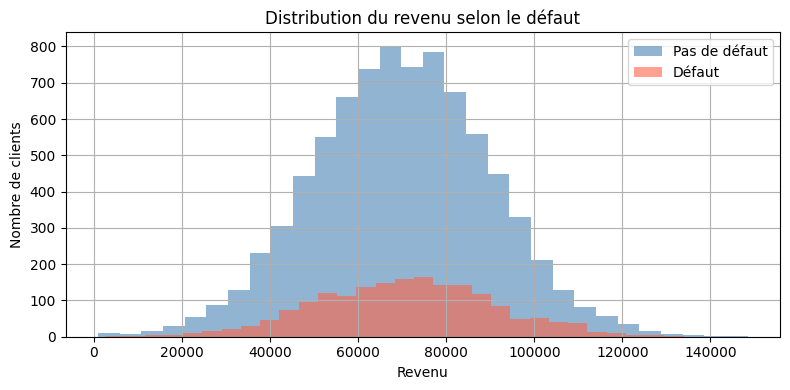

In [20]:
# Revenu selon le défaut
plt.figure(figsize=(8,4))
df[df['default']==0]['income'].hist(alpha=0.6, label='Pas de défaut', color='steelblue', bins=30)
df[df['default']==1]['income'].hist(alpha=0.6, label='Défaut', color='tomato', bins=30)
plt.title("Distribution du revenu selon le défaut")
plt.xlabel("Revenu")
plt.ylabel("Nombre de clients")
plt.legend()
plt.tight_layout()
plt.show()


Observations : Les revenus des clients en défaut et sans défaut sont similaires, le revenu seul n'est pas très utile pour prédire un défaut.

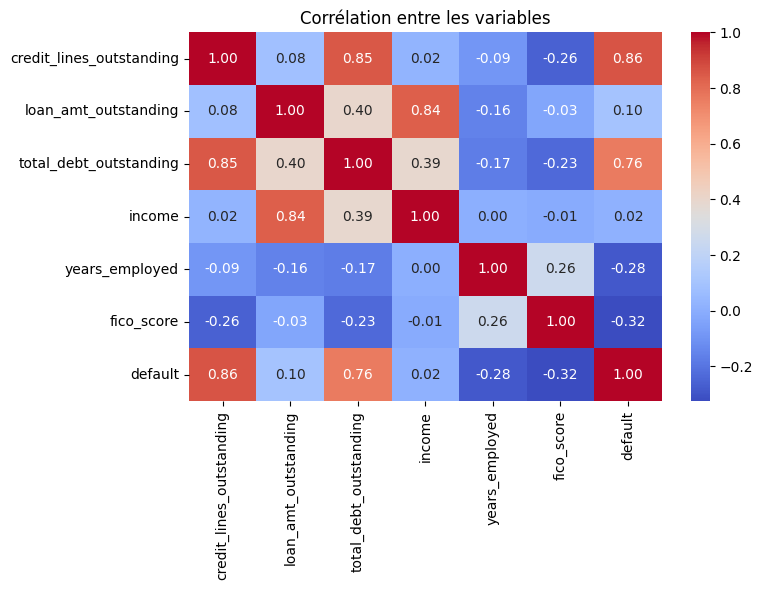

In [21]:
# Corrélation entre toutes les variables
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('customer_id', axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Corrélation entre les variables")
plt.tight_layout()
plt.show()

Observation : Les variables les plus liées au défaut sont credit_lines_outstanding (Plus de crédits = plus de risque), total_debt_outstanding (Plus de dettes = plus de risque), fico_score (Plus le score est bas = plus de risque)

## **Selection des variables**

In [23]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

In [27]:
# Sélection des variables avec Random Forest
X_new = df_clean.drop('default', axis=1)
y = df_clean['default']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_new, y)

RandomForestClassifier(random_state=42)

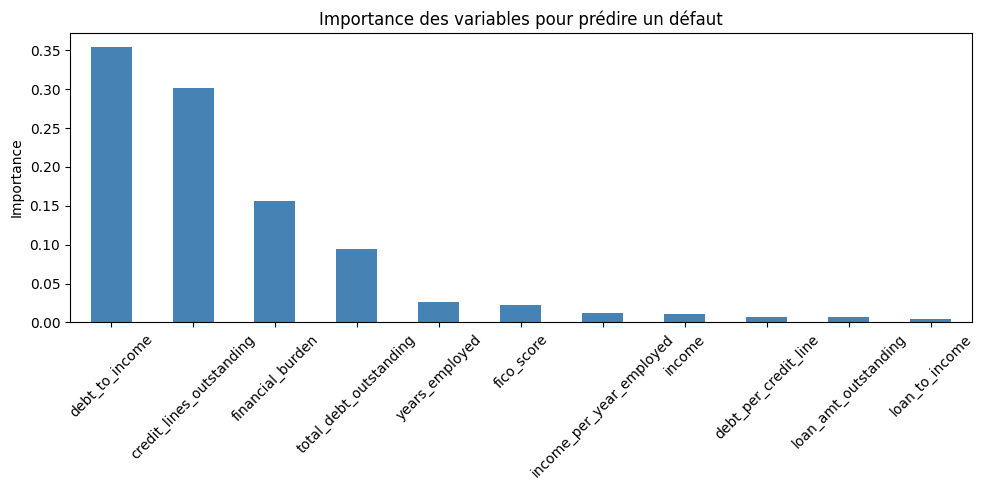


Variables classées par importance :
  debt_to_income : 0.3548
  credit_lines_outstanding : 0.3019
  financial_burden : 0.1564
  total_debt_outstanding : 0.0947
  years_employed : 0.0267
  fico_score : 0.0228
  income_per_year_employed : 0.0128
  income : 0.0107
  debt_per_credit_line : 0.0077
  loan_amt_outstanding : 0.0068
  loan_to_income : 0.0047


In [28]:
# Afficher l'importance des variables
importances = pd.Series(rf.feature_importances_, index=X_new.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title("Importance des variables pour prédire un défaut")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nVariables classées par importance :")
for col, val in importances.items():
    print(f"  {col} : {val:.4f}")

In [29]:
# On garde uniquement les variables importantes (importance > 0.05)
variables_selectionnees = importances[importances > 0.05].index.tolist()

print("Variables sélectionnées :", variables_selectionnees)

X_new = df_clean[variables_selectionnees]
print("Nouvelle taille du dataset :", X_new.shape)

Variables sélectionnées : ['debt_to_income', 'credit_lines_outstanding', 'financial_burden', 'total_debt_outstanding']
Nouvelle taille du dataset : (10000, 4)


## **Nettoyage et préparation des données**

In [30]:
# Suppression de la colonne inutile customer_id
df_clean = df_clean.drop('customer_id', axis=1) if 'customer_id' in df_clean.columns else df_clean

# Séparation des variables sélectionnées (X) et de la cible (y)
X = df_clean[variables_selectionnees]
y = df_clean['default']

# Normalisation des données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Données prêtes pour la modélisation")
print("Variables utilisées :", variables_selectionnees)
print("Taille du dataset :", X_scaled.shape)

Données prêtes pour la modélisation
Variables utilisées : ['debt_to_income', 'credit_lines_outstanding', 'financial_burden', 'total_debt_outstanding']
Taille du dataset : (10000, 4)


In [31]:
# Afficher les données nettoyées
print("Aperçu des données prêtes pour la modélisation :")
pd.DataFrame(X_scaled, columns=X.columns).head()

Aperçu des données prêtes pour la modélisation :


,debt_to_income,credit_lines_outstanding,financial_burden,total_debt_outstanding
0,-0.891868,-0.837960,-0.747465,-0.724848
1,2.231588,2.029409,0.418879,-0.073967
2,-1.126005,-0.837960,-0.747465,-1.009696
3,-1.091487,-0.837960,-0.747465,-0.938184
4,-0.586763,-0.264486,-0.587205,-1.048780


In [32]:
import numpy as np
from google.colab import files

# Sauvegarde de X et y
np.save("X_scaled.npy", X_scaled)
np.save("y.npy", y.values)
df_clean.to_csv("Loan_Data_clean.csv", index=False)

# Téléchargement sur ton ordi
files.download("Loan_Data_clean.csv")
files.download("X_scaled.npy")
files.download("y.npy")

print("✅ Fichiers téléchargés !")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Fichiers téléchargés !
